# Segmentación interactiva con GrabCut

Este cuaderno presenta el algoritmo **GrabCut** para la segmentación interactiva de lesiones en imágenes de resonancia magnética cerebral.

El método se estudiará en dos etapas:

1. **Implementación didáctica:** se desarrollarán paso a paso los principales componentes matemáticos de GrabCut: modelo de mezclas gaussianas, costos de apariencia, coherencia espacial, construcción del grafo y corte mínimo.
2. **Implementación con OpenCV:** se utilizará `cv2.grabCut` para observar cómo estos pasos son encapsulados por una implementación optimizada.

Finalmente, ambas segmentaciones se compararán con una máscara de referencia mediante el **error cuadrático medio (ECM)**.

## 1. Ruta de la exposición (60 minutos)

| Bloque | Tiempo orientativo |
|---|---:|
| Imagen, ROI e inicialización (1–4) | 8 min |
| Mezclas gaussianas (5) | 12 min |
| Apariencia, término espacial y grafo (6–8) | 12 min |
| Flujo máximo y corte mínimo (9) | 10 min |
| Alternancia completa (10) | 6 min |
| OpenCV, referencia y MSE (11–13) | 12 min |

En la sección 9 conviene concentrar la explicación en capacidades, residual y ejemplo de tres píxeles; el detalle de Dinic queda disponible como apoyo. El núcleo didáctico es una variante en escala de grises del método de [Rother, Kolmogorov y Blake (2004)](https://www.microsoft.com/en-us/research/publication/grabcut-interactive-foreground-extraction-using-iterated-graph-cuts/), sin refinamiento de bordes ni trazos adicionales.

**Ejecución para la presentación:** use el entorno del repositorio, ejecute hasta la sección 3 y seleccione manualmente la ROI. Después continúe desde la sección 4, respetando el orden. La pausa es parte de la actividad: ejecutar todo sin seleccionar el rectángulo no constituye una prueba válida. Las figuras y tablas guardadas documentan el caso y la ROI indicados en la sección 3.


In [1]:
%matplotlib widget

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

## 2. Imagen de trabajo

Sea $x_i$ la intensidad del píxel $i$ de una imagen en escala de grises.

Para desarrollar el algoritmo se utilizará un único caso como ejemplo. Cada caso del conjunto de datos está identificado mediante la convención `VS-SEG-XXX`.

La imagen original se encuentra en:

```text
data/images/
```

Durante las siguientes secciones, esta imagen permitirá construir paso a paso los modelos probabilísticos y espaciales utilizados por GrabCut.

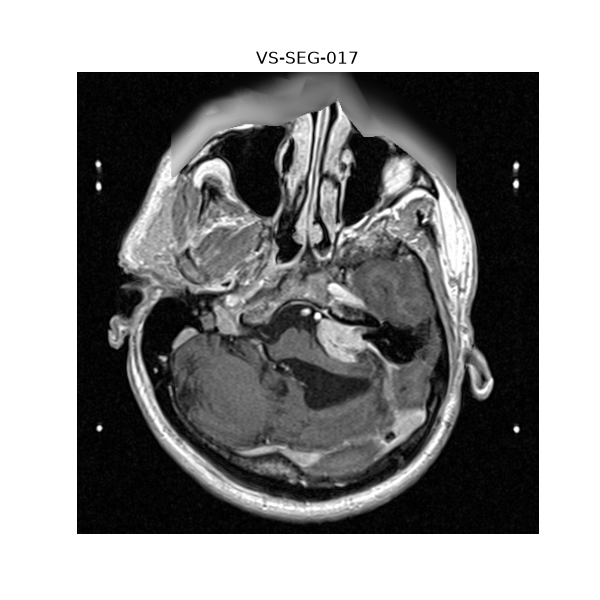

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

case_id = "VS-SEG-017"
image_path = DATA_DIR / "images" / f"{case_id}.png"

image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title(case_id)
plt.axis("off")
plt.show()

## 3. Selección interactiva de la ROI

GrabCut utiliza una **región de interés (ROI)** para inicializar la segmentación.

La ROI se representa mediante el rectángulo

$$
R=(x,y,w,h),
$$

donde $(x,y)$ corresponde a la esquina superior izquierda, mientras que $w$ y $h$ representan su ancho y altura.

El usuario selecciona una región que contiene la lesión y parte del tejido circundante. Los píxeles exteriores se utilizarán inicialmente como **fondo seguro**, mientras que los píxeles interiores constituirán la región candidata para la segmentación.

El rectángulo rojo puede reajustarse interactivamente y no representa el contorno final de la lesión; únicamente proporciona la inicialización espacial del algoritmo.

**Pausa de la exposición:** ejecute la celda siguiente, dibuje o ajuste el rectángulo y solo entonces continúe con la sección 4. Si cambia la ROI más tarde, vuelva a ejecutar desde la sección 4 para actualizar todos los resultados.

Las salidas guardadas muestran una ejecución de revisión con $R=(250,253,89,84)$ para el caso `VS-SEG-017`. Al volver a ejecutar, la selección sigue siendo manual; no se impone ese rectángulo.

Las figuras guardadas son capturas estáticas. Al ejecutar la celda siguiente se activa nuevamente el selector interactivo.


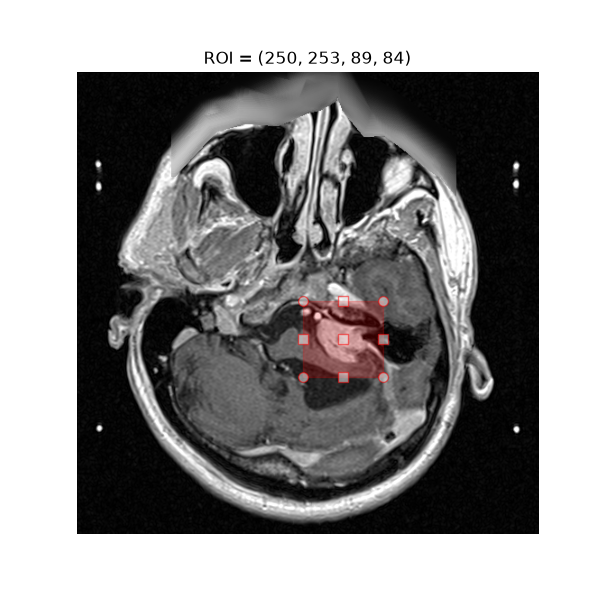

In [4]:
from IPython.display import display
from matplotlib.widgets import RectangleSelector

roi_state = {}


def on_select(eclick, erelease):
    x1, y1 = eclick.xdata, eclick.ydata
    x2, y2 = erelease.xdata, erelease.ydata

    roi_state["value"] = (
        int(min(x1, x2)),
        int(min(y1, y2)),
        int(abs(x2 - x1)),
        int(abs(y2 - y1)),
    )

    selector.ax.set_title(f"ROI = {roi_state['value']}")
    selector.ax.figure.canvas.draw_idle()


with plt.ioff():
    fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(image, cmap="gray")
ax.set_title("Seleccione la ROI")
ax.axis("off")

selector = RectangleSelector(
    ax,
    on_select,
    button=[1],
    interactive=True,
    useblit=False,
    props={
        "edgecolor": "red",
        "facecolor": "red",
        "alpha": 0.2,
        "fill": True,
    },
)

display(fig.canvas)

## 4. Inicialización de etiquetas

A cada píxel $i$ se le asigna una etiqueta provisional

$$
\alpha_i \in \{0,1\},
$$

donde

$$
\alpha_i =
\begin{cases}
0, & \text{si el píxel pertenece al fondo},\\
1, & \text{si el píxel pertenece a la región candidata}.
\end{cases}
$$

La ROI seleccionada en la sección anterior proporciona la inicialización:

- los píxeles **fuera** del rectángulo se consideran fondo seguro;
- los píxeles **dentro** del rectángulo se consideran provisionalmente parte de la región candidata.

Esta clasificación todavía no constituye la segmentación final. Su propósito es proporcionar muestras iniciales para estimar los modelos de apariencia de fondo y primer plano.

In [6]:
x, y, w, h = roi_state["value"]

labels = np.zeros_like(image, dtype=np.uint8)
labels[y:y + h, x:x + w] = 1

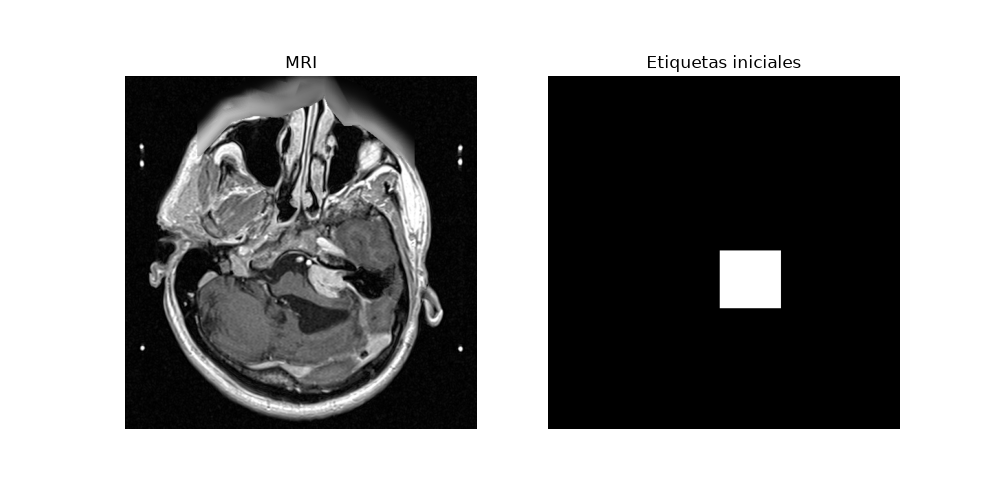

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("MRI")

axes[1].imshow(labels, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Etiquetas iniciales")

for ax in axes:
    ax.axis("off")

plt.show()

## 5. Modelo de mezclas gaussianas

### 5.1. Muestras de fondo y primer plano

Se utilizarán $K=5$ componentes gaussianos para modelar cada clase.

A partir de las etiquetas iniciales $\alpha_i^{(0)}$, las intensidades se separan en dos conjuntos:

$$
X_{\mathrm{BG}}
=
\{x_i:\alpha_i^{(0)}=0\},
$$

$$
X_{\mathrm{FG}}
=
\{x_i:\alpha_i^{(0)}=1\}.
$$

El conjunto $X_{\mathrm{BG}}$ contiene las intensidades correspondientes al fondo seguro, mientras que $X_{\mathrm{FG}}$ contiene las intensidades de la región candidata.

Como la ROI incluye tanto la lesión como tejido circundante, $X_{\mathrm{FG}}$ no representa una única población homogénea. La mezcla de gaussianas permite representar distintos grupos de intensidades dentro de una misma clase.

In [8]:
K = 5

background_pixels = image[labels == 0].astype(np.float64)
foreground_pixels = image[labels == 1].astype(np.float64)

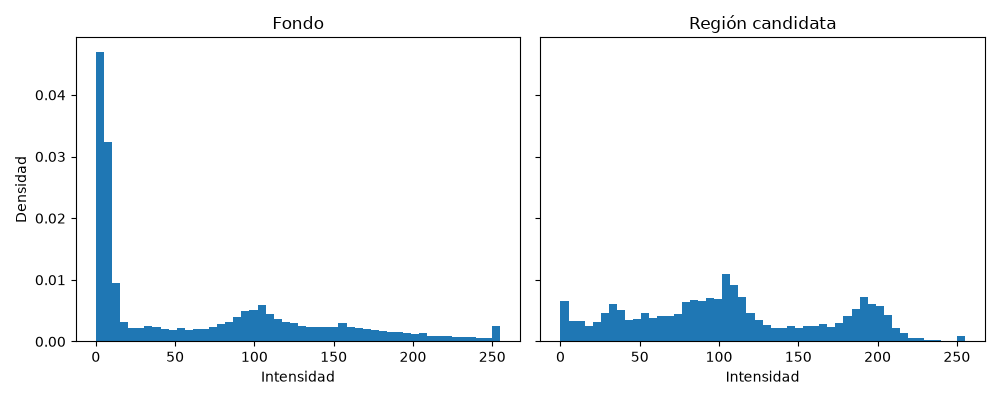

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].hist(background_pixels, bins=50, density=True)
axes[0].set_title("Fondo")
axes[0].set_xlabel("Intensidad")

axes[1].hist(foreground_pixels, bins=50, density=True)
axes[1].set_title("Región candidata")
axes[1].set_xlabel("Intensidad")

axes[0].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

### 5.2. Inicialización de los componentes gaussianos

Antes de ajustar la mezcla es necesario proporcionar una estimación inicial de sus parámetros.

Para cada clase, las intensidades se ordenan y se dividen en $K=5$ grupos de tamaño aproximadamente igual:

$$
X_a = X_{a1} \cup X_{a2} \cup \cdots \cup X_{aK}.
$$

Para cada grupo $X_{ak}$ se calculan los parámetros iniciales

$$
w_{ak}
=
\frac{N_{ak}}{N_a},
$$

$$
\mu_{ak}
=
\frac{1}{N_{ak}}
\sum_{x_i \in X_{ak}} x_i,
$$

$$
\sigma_{ak}^2
=
\frac{1}{N_{ak}}
\sum_{x_i \in X_{ak}}
(x_i-\mu_{ak})^2,
$$

donde $N_{ak}$ es el número de píxeles asignados al componente $k$ y $N_a$ es el número total de píxeles de la clase.

Esta partición proporciona una inicialización simple y determinista de las cinco gaussianas. Posteriormente, los píxeles se reasignarán según el modelo probabilístico y los parámetros se volverán a estimar.

In [10]:
def initialize_gmm(samples, K):
    groups = np.array_split(np.sort(samples), K)

    weights = np.array([len(group) / len(samples) for group in groups])
    means = np.array([group.mean() for group in groups])
    variances = np.array([group.var() + 1e-6 for group in groups])

    return weights, means, variances

In [11]:
bg_weights, bg_means, bg_variances = initialize_gmm(background_pixels, K)
fg_weights, fg_means, fg_variances = initialize_gmm(foreground_pixels, K)

In [12]:
print("Background")
print("weights:   ", np.round(bg_weights, 3))
print("means:     ", np.round(bg_means, 2))
print("variances: ", np.round(bg_variances, 2))

print("\nForeground")
print("weights:   ", np.round(fg_weights, 3))
print("means:     ", np.round(fg_means, 2))
print("variances: ", np.round(fg_variances, 2))

Background
weights:    [0.2 0.2 0.2 0.2 0.2]
means:      [  2.46   7.03  37.74 103.93 180.31]
variances:  [   2.04    2.42  519.17  169.39 1302.19]

Foreground
weights:    [0.2 0.2 0.2 0.2 0.2]
means:      [ 23.47  70.05 101.39 140.85 198.33]
variances:  [200.66 147.94  50.34 434.98 205.5 ]


### 5.3. Visualización de la mezcla inicial

Para cada clase $a\in\{0,1\}$, un componente tiene densidad

$$\mathcal N(x;\mu_{ak},\sigma_{ak}^2)
=\frac{1}{\sqrt{2\pi\sigma_{ak}^2}}
\exp\left[-\frac{(x-\mu_{ak})^2}{2\sigma_{ak}^2}\right].$$

Su contribución es $w_{ak}\mathcal N(x;\mu_{ak},\sigma_{ak}^2)$ y la densidad total es

$$p(x\mid a)=\sum_{k=1}^{K}w_{ak}\mathcal N(x;\mu_{ak},\sigma_{ak}^2).$$

Superponemos las cinco contribuciones y su suma sobre el histograma normalizado. Los pesos suman uno; las alturas de las curvas son **densidades**, no probabilidades de un valor exacto. Las gaussianas se definen en toda la recta, aunque mostramos el intervalo de intensidades $[0,255]$.

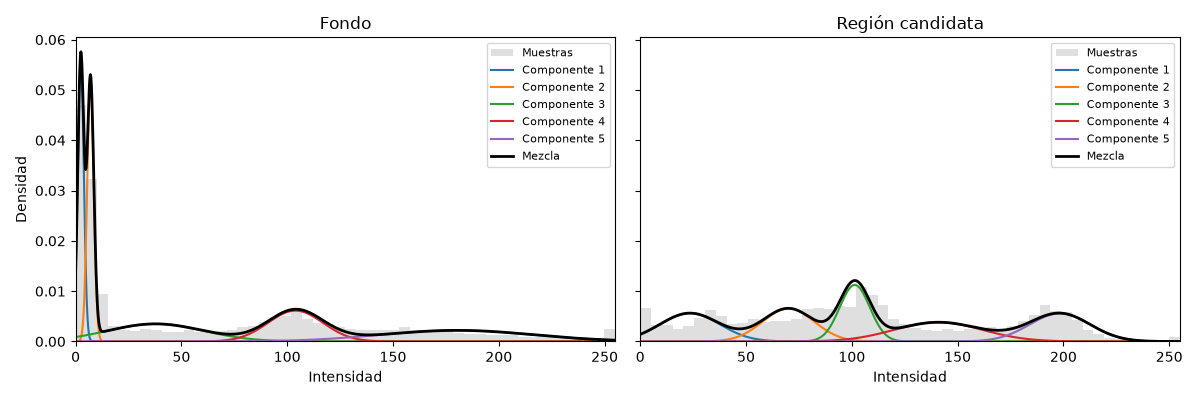

In [15]:
def gaussian_pdf(x, mean, variance):
    return np.exp(-0.5 * (x - mean) ** 2 / variance) / np.sqrt(2 * np.pi * variance)


intensity_axis = np.linspace(0, 255, 1024)
initial_models = [
    (background_pixels, bg_weights, bg_means, bg_variances, "Fondo"),
    (foreground_pixels, fg_weights, fg_means, fg_variances, "Región candidata"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (samples, weights, means, variances, title) in zip(axes, initial_models):
    ax.hist(samples, bins=50, density=True, alpha=0.25, color="gray", label="Muestras")
    mixture = np.zeros_like(intensity_axis)
    for k, (weight, mean, variance) in enumerate(zip(weights, means, variances)):
        component = weight * gaussian_pdf(intensity_axis, mean, variance)
        mixture += component
        ax.plot(intensity_axis, component, label=f"Componente {k + 1}")
    ax.plot(intensity_axis, mixture, color="black", linewidth=2, label="Mezcla")
    ax.set(title=title, xlabel="Intensidad", xlim=(0, 255))
    ax.legend(fontsize=8)
axes[0].set_ylabel("Densidad")
plt.tight_layout()
plt.show()

### 5.4. Asignación de componentes

Con la clase $a$ fija, asignamos cada intensidad al componente de mayor contribución ponderada:

$$k_i=\arg\max_k w_{ak}\mathcal N(x_i;\mu_{ak},\sigma_{ak}^2)
=\arg\min_k d_{ak}(x_i),$$

$$d_{ak}(x)=-\log w_{ak}+\frac12\log(2\pi\sigma_{ak}^2)
+\frac{(x-\mu_{ak})^2}{2\sigma_{ak}^2}.$$

Trabajar en logaritmos evita que una exponencial muy pequeña se redondee a cero. Un componente con peso cero recibe costo $+\infty$ y queda inactivo. La asignación es **dura**: cada píxel elige un componente, sin responsabilidades fraccionarias de EM.

Esta operación cambia $k_i$, **no** la etiqueta $\alpha_i$. El mapa muestra índices locales a cada clase: el componente 1 del fondo no tiene por qué parecerse al componente 1 del primer plano.

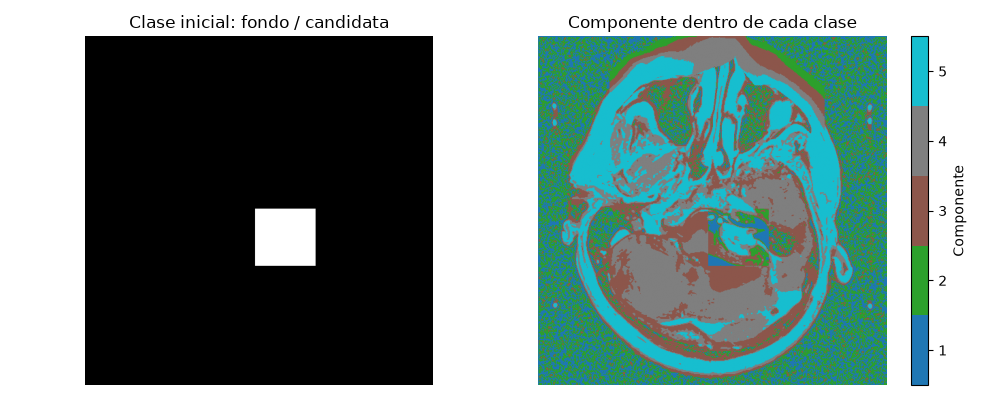

Píxeles por componente de fondo: [48693 58231 43785 52752 51207]
Píxeles por componente candidato: [1519 1483 1633 1214 1627]


In [19]:
def component_costs(samples, weights, means, variances):
    log_weights = np.full_like(weights, -np.inf)
    np.log(weights, out=log_weights, where=weights > 0)
    return (
        -log_weights
        + 0.5 * np.log(2 * np.pi * variances)
        + 0.5 * (samples[..., None] - means) ** 2 / variances
    )


bg_components = component_costs(
    background_pixels, bg_weights, bg_means, bg_variances
).argmin(axis=-1)
fg_components = component_costs(
    foreground_pixels, fg_weights, fg_means, fg_variances
).argmin(axis=-1)
component_map = np.zeros_like(labels)
component_map[labels == 0] = bg_components
component_map[labels == 1] = fg_components

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(labels, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Clase inicial: fondo / candidata")
plot = axes[1].imshow(component_map + 1, cmap=plt.get_cmap("tab10", K), vmin=0.5, vmax=5.5)
axes[1].set_title("Componente dentro de cada clase")
fig.colorbar(plot, ax=axes[1], ticks=range(1, K + 1), label="Componente")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
print("Píxeles por componente de fondo:", np.bincount(bg_components, minlength=K))
print("Píxeles por componente candidato:", np.bincount(fg_components, minlength=K))

### 5.5. Actualización de los parámetros

Con las asignaciones de 5.4 definimos $X_{ak}=\{x_i:\alpha_i=a,\ k_i=k\}$. Reestimamos

$$w_{ak}=\frac{|X_{ak}|}{|X_a|},\qquad
\mu_{ak}=\frac{1}{|X_{ak}|}\sum_{x\in X_{ak}}x,$$

$$\sigma_{ak}^2=\frac{1}{|X_{ak}|}\sum_{x\in X_{ak}}(x-\mu_{ak})^2+\varepsilon,
\qquad\varepsilon=10^{-6}.$$

La varianza positiva permite evaluar el logaritmo y la división. Si un componente queda vacío, su peso pasa a cero y conservamos su media y varianza anteriores, que ya no contribuyen a la mezcla. Si desaparece toda una clase durante las iteraciones, conservaremos su último modelo.

Hacemos **una actualización** y comparamos la mezcla inicial con la actualizada. Después alternaremos esta operación con el corte del grafo; aquí las etiquetas siguen fijas.

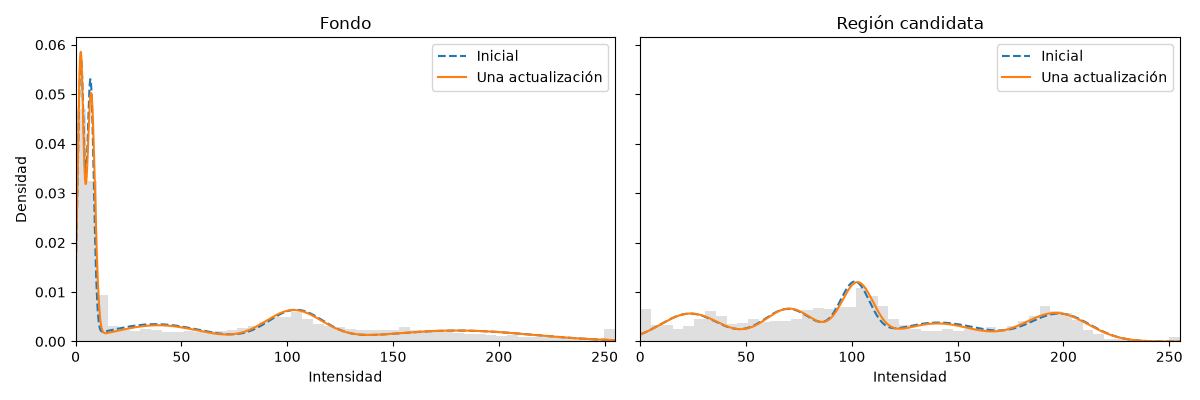

In [20]:
def update_gmm(samples, components, weights, means, variances):
    if samples.size == 0:
        return weights.copy(), means.copy(), variances.copy()
    weights = np.zeros_like(weights)
    means, variances = means.copy(), variances.copy()
    for k in range(len(weights)):
        group = samples[components == k]
        weights[k] = group.size / samples.size
        if group.size:
            means[k] = group.mean()
            variances[k] = group.var() + 1e-6
    return weights, means, variances


bg_weights, bg_means, bg_variances = update_gmm(
    background_pixels, bg_components, bg_weights, bg_means, bg_variances
)
fg_weights, fg_means, fg_variances = update_gmm(
    foreground_pixels, fg_components, fg_weights, fg_means, fg_variances
)
updated_models = [
    (bg_weights, bg_means, bg_variances),
    (fg_weights, fg_means, fg_variances),
]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, initial, updated in zip(axes, initial_models, updated_models):
    samples, weights, means, variances, title = initial
    before = (weights * gaussian_pdf(intensity_axis[:, None], means, variances)).sum(axis=1)
    weights, means, variances = updated
    after = (weights * gaussian_pdf(intensity_axis[:, None], means, variances)).sum(axis=1)
    ax.hist(samples, bins=50, density=True, color="gray", alpha=0.25)
    ax.plot(intensity_axis, before, "--", label="Inicial")
    ax.plot(intensity_axis, after, label="Una actualización")
    ax.set(title=title, xlabel="Intensidad", xlim=(0, 255))
    ax.legend()
axes[0].set_ylabel("Densidad")
plt.tight_layout()
plt.show()

## 6. Costos de apariencia

Para decidir la clase sumamos las contribuciones de **todos** sus componentes:

$$D_i(a)=-\log p(x_i\mid a)
=-\log\sum_{k=1}^{K}\exp[-d_{ak}(x_i)].$$

`logaddexp.reduce` calcula este logaritmo de una suma de exponenciales de forma estable. No necesitamos recortar probabilidades ni calcular $\log(0)$. Una densidad puede superar uno, de modo que un costo puede ser negativo.

Con los modelos fijos, la decisión por apariencia es $\alpha_i=\arg\min_a D_i(a)$. La diferencia $D_i(0)-D_i(1)>0$ favorece primer plano. Restringimos la decisión a la ROI: el exterior sigue siendo fondo seguro.

**Distinción del modelo:** la asignación dura de 5.4 usa un componente; el costo de segmentación marginaliza la mezcla. Esta variante didáctica combina ajuste duro y costo marginal, como estrategia de alternancia. No es EM con responsabilidades suaves ni implica descenso garantizado del costo marginal al reajustar los GMM.

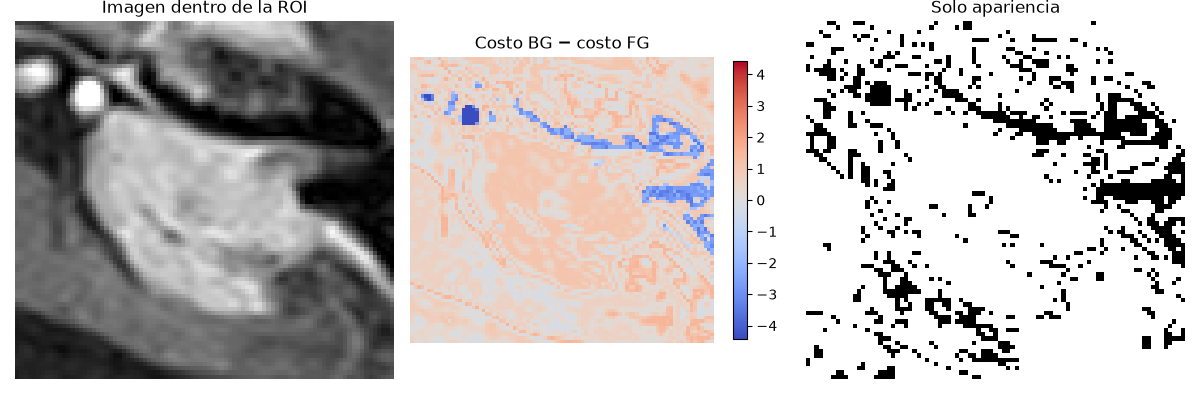

In [22]:
def gmm_cost(samples, weights, means, variances):
    return -np.logaddexp.reduce(-component_costs(samples, weights, means, variances), axis=-1)


values = image.astype(np.float64)
roi_mask = labels.astype(bool).copy()
initial_labels = labels.copy()
models = [
    (bg_weights, bg_means, bg_variances),
    (fg_weights, fg_means, fg_variances),
]
costs = np.stack([gmm_cost(values, *model) for model in models], axis=-1)
appearance_labels = ((costs[..., 1] < costs[..., 0]) & roi_mask).astype(np.uint8)
roi_slice = np.s_[y:y + h, x:x + w]
margin = (costs[..., 0] - costs[..., 1])[roi_slice]
limit = np.abs(margin).max()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image[roi_slice], cmap="gray")
axes[0].set_title("Imagen dentro de la ROI")
plot = axes[1].imshow(margin, cmap="coolwarm", vmin=-limit, vmax=limit)
axes[1].set_title("Costo BG − costo FG")
fig.colorbar(plot, ax=axes[1], shrink=0.75)
axes[2].imshow(appearance_labels[roi_slice], cmap="gray", vmin=0, vmax=1)
axes[2].set_title("Solo apariencia")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Término espacial

La apariencia clasifica píxeles por separado. Para favorecer regiones coherentes añadimos

$$E(\alpha;\theta)=\sum_i D_i(\alpha_i)+
\underbrace{\sum_{\{i,j\}\in\mathcal N}v_{ij}[\alpha_i\ne\alpha_j]}_{V(\alpha)},$$

$$v_{ij}=\frac{\gamma}{\operatorname{dist}(i,j)}
\exp[-\beta(x_i-x_j)^2],\qquad
\beta=\frac{1}{2\,\operatorname{media}_{\mathcal N}(x_i-x_j)^2}.$$

Usamos vecindad de ocho vecinos y contamos cada par **una sola vez**: derecha, abajo y dos diagonales. La distancia es 1 en horizontal/vertical y $\sqrt2$ en diagonal. Tomamos $\gamma=50$; si la imagen es constante usamos $\beta=0$.

Un peso grande penaliza separar píxeles parecidos. Un borde de alto contraste reduce el peso y facilita que pase el corte. La visualización muestra los enlaces horizontales dentro de la ROI; el cálculo incluye también verticales, diagonales y el resto de la imagen.

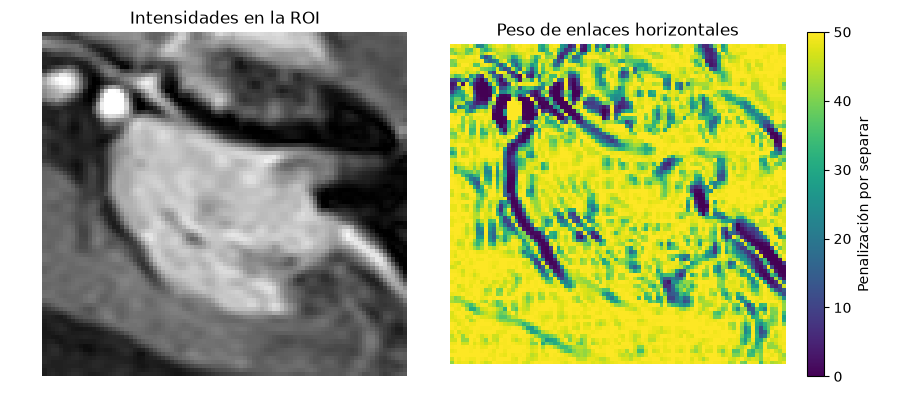

β = 0.002193; γ = 50; pares únicos = 1,045,506


In [24]:
height, width = image.shape
pixel_ids = np.arange(image.size).reshape(image.shape)
pairs = [
    (pixel_ids[:, :-1], pixel_ids[:, 1:], 1.0),
    (pixel_ids[:-1, :], pixel_ids[1:, :], 1.0),
    (pixel_ids[:-1, :-1], pixel_ids[1:, 1:], np.sqrt(2)),
    (pixel_ids[:-1, 1:], pixel_ids[1:, :-1], np.sqrt(2)),
]
edge_i = np.concatenate([left.ravel() for left, right, distance in pairs])
edge_j = np.concatenate([right.ravel() for left, right, distance in pairs])
distances = np.concatenate([np.full(left.size, distance) for left, right, distance in pairs])
squared_differences = (values.ravel()[edge_i] - values.ravel()[edge_j]) ** 2
mean_difference = squared_differences.mean()
beta = 1 / (2 * mean_difference) if mean_difference > 0 else 0.0
gamma = 50.0
edge_weights = gamma * np.exp(-beta * squared_differences) / distances
horizontal_weights = edge_weights[:height * (width - 1)].reshape(height, width - 1)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(image[roi_slice], cmap="gray")
axes[0].set_title("Intensidades en la ROI")
plot = axes[1].imshow(horizontal_weights[y:y + h, x:x + w - 1], cmap="viridis", vmin=0, vmax=gamma)
axes[1].set_title("Peso de enlaces horizontales")
fig.colorbar(plot, ax=axes[1], label="Penalización por separar")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"β = {beta:.6f}; γ = {gamma:g}; pares únicos = {edge_weights.size:,}")

## 8. Construcción del grafo

### 8.1. Incorporar el fondo seguro sin penalizaciones artificiales

Como $\alpha_j=0$ fuera de $R$, un enlace entre $i\in R$ y $j\notin R$ aporta $v_{ij}[\alpha_i=1]$. Podemos eliminar esos nodos fijos y sumar sus pesos al costo de primer plano:

$$b_i=\sum_{j\notin R:\{i,j\}\in\mathcal N}v_{ij},\qquad
\widetilde D_i(0)=D_i(0),\quad \widetilde D_i(1)=D_i(1)+b_i.$$

Así, para los modelos fijos,

$$E(\alpha;\theta)=C_{\mathrm{fuera}}+
\sum_{i\in R}\widetilde D_i(\alpha_i)+
\sum_{\{i,j\}\subset R}v_{ij}[\alpha_i\ne\alpha_j],\qquad
C_{\mathrm{fuera}}=\sum_{i\notin R}D_i(0).$$

Es una reducción **exacta**: no se pierde el borde del rectángulo ni se necesita simular infinito. Los GMM y $\beta$ siguen usando la imagen completa. Asignamos índices consecutivos solo a los píxeles de la ROI; los vecinos exteriores conservan índice −1.

In [26]:
local_ids = np.full(image.size, -1, dtype=int)
local_ids[roi_mask.ravel()] = np.arange(roi_mask.sum())
local_i, local_j = local_ids[edge_i], local_ids[edge_j]
inside_i, inside_j = local_i >= 0, local_j >= 0
internal = inside_i & inside_j
roi_edges = np.column_stack((local_i[internal], local_j[internal]))
roi_weights = edge_weights[internal]

boundary_cost = np.zeros(roi_mask.sum())
crossing = inside_i & ~inside_j
np.add.at(boundary_cost, local_i[crossing], edge_weights[crossing])
crossing = inside_j & ~inside_i
np.add.at(boundary_cost, local_j[crossing], edge_weights[crossing])

roi_costs = costs[roi_mask].copy()
roi_costs[:, 1] += boundary_cost
outside_cost = costs[~roi_mask, 0].sum()
print(f"Nodos variables: {roi_mask.sum():,} de {image.size:,} píxeles")
print(f"Pares internos: {len(roi_edges):,}")
print(f"Píxeles con vecinos exteriores: {np.count_nonzero(boundary_cost):,}")

Nodos variables: 7,476 de 262,144 píxeles
Pares internos: 29,387
Píxeles con vecinos exteriores: 342


### 8.2. Capacidades terminales y aristas residuales

Fijamos la convención: **fuente $s$ = primer plano (1)** y **sumidero $t$ = fondo (0)**. Restamos a cada par de costos el mínimo $m_i=\min_a\widetilde D_i(a)$:

$$c(s,i)=\widetilde D_i(0)-m_i,\qquad
c(i,t)=\widetilde D_i(1)-m_i.$$

Ambas capacidades son no negativas. Restar $m_i$ no cambia la etiqueta óptima: solo elimina la constante $\sum_i m_i$.

| Etiqueta de $i$ | Lado del corte | Arista terminal cortada | Costo |
|---|---|---|---|
| 0 | Sumidero | $s\to i$ | $\widetilde D_i(0)-m_i$ |
| 1 | Fuente | $i\to t$ | $\widetilde D_i(1)-m_i$ |

Cada par interno tiene dos arcos opuestos de capacidad $v_{ij}$. Si las etiquetas difieren, solo uno cruza de fuente a sumidero y se paga $v_{ij}$, no $2v_{ij}$.

Guardamos cada arco como `[destino, índice_del_inverso, capacidad_residual]`. El arco inverso permitirá cancelar flujo durante la búsqueda. Para los terminales comienza en cero; para los vecinos comienza con el peso simétrico.

In [28]:
def add_edge(graph, start, end, capacity, reverse_capacity=0.0):
    graph[start].append([end, len(graph[end]), float(capacity)])
    graph[end].append([start, len(graph[start]) - 1, float(reverse_capacity)])


def build_graph(unary_costs, edges, weights):
    node_count = len(unary_costs)
    source, sink = node_count, node_count + 1
    graph = [[] for _ in range(node_count + 2)]
    minimum = unary_costs.min(axis=1)
    capacities = unary_costs - minimum[:, None]
    for i, (background_cost, foreground_cost) in enumerate(capacities):
        add_edge(graph, source, i, background_cost)
        add_edge(graph, i, sink, foreground_cost)
    for (i, j), weight in zip(edges, weights):
        add_edge(graph, int(i), int(j), weight, weight)
    return graph, source, sink, minimum.sum()


graph, source, sink, unary_offset = build_graph(roi_costs, roi_edges, roi_weights)
print(f"Fuente: {source}; sumidero: {sink}")
print(f"Arcos residuales almacenados: {sum(map(len, graph)):,}")
print(f"Constante de costos retirada: {unary_offset:.3f}")

Fuente: 7476; sumidero: 7477
Arcos residuales almacenados: 88,678
Constante de costos retirada: 39532.347


## 9. Corte mínimo y flujo máximo

### 9.1. Caminos en el grafo residual

El teorema de flujo máximo–corte mínimo permite encontrar la segmentación óptima **con los modelos fijos**. Buscamos caminos $s\leadsto t$ por arcos con capacidad residual positiva.

Una búsqueda en anchura (BFS) calcula niveles $\ell(v)$: la menor cantidad de arcos desde $s$. El valor −1 indica que no hay camino residual. Para capacidades en punto flotante consideramos positivo un residual mayor que $10^{-10}$.

Cuando $t$ ya no sea alcanzable, los nodos alcanzables desde $s$ formarán el primer plano. Primero probamos BFS sobre una cadena de tres píxeles, cuyos costos de fondo/primer plano son $(0,4)$, $(2,1)$ y $(5,0)$; ambos enlaces espaciales pesan 1.5.

In [30]:
from collections import deque


def residual_levels(graph, source, tolerance=1e-10):
    levels = [-1] * len(graph)
    levels[source] = 0
    queue = deque([source])
    while queue:
        u = queue.popleft()
        for v, reverse, capacity in graph[u]:
            if capacity > tolerance and levels[v] < 0:
                levels[v] = levels[u] + 1
                queue.append(v)
    return levels


toy_costs = np.array([[0.0, 4.0], [2.0, 1.0], [5.0, 0.0]])
toy_edges = np.array([[0, 1], [1, 2]])
toy_weights = np.array([1.5, 1.5])
toy_graph, toy_source, toy_sink, toy_offset = build_graph(toy_costs, toy_edges, toy_weights)
print("Niveles [píxel 0, píxel 1, píxel 2, fuente, sumidero]:")
print(residual_levels(toy_graph, toy_source))

Niveles [píxel 0, píxel 1, píxel 2, fuente, sumidero]:
[2, 1, 1, 0, 3]


### 9.2. Aumentar el flujo hasta bloquear los caminos

Usamos el algoritmo de **Dinic**: BFS establece niveles y una búsqueda en profundidad envía flujo por arcos que avanzan exactamente un nivel. Para un camino $P$, el aumento está limitado por su cuello de botella:

$$\Delta=\min_{(u,v)\in P}r(u,v).$$

Cada aumento actualiza los residuales

$$r(u,v)\leftarrow r(u,v)-\Delta,\qquad
r(v,u)\leftarrow r(v,u)+\Delta.$$

El arco inverso permite deshacer decisiones previas. `current` recuerda los arcos ya agotados para no recorrerlos de nuevo en el mismo conjunto de niveles. Cuando no se puede enviar más flujo, recalculamos BFS; cuando el sumidero deja de ser alcanzable, terminamos.

La función modifica el grafo residual. Por eso construimos un grafo nuevo antes de resolver cada corte. Esta implementación en Python prioriza hacer visible el procedimiento; el problema se limita exactamente a los nodos de la ROI.

In [32]:
def maximum_flow(graph, source, sink, tolerance=1e-10):
    total_flow = 0.0

    def send_flow(u, available):
        if u == sink:
            return available
        while current[u] < len(graph[u]):
            edge = graph[u][current[u]]
            v, reverse, capacity = edge
            if capacity > tolerance and levels[v] == levels[u] + 1:
                sent = send_flow(v, min(available, capacity))
                if sent > tolerance:
                    edge[2] -= sent
                    graph[v][reverse][2] += sent
                    return sent
            current[u] += 1
        return 0.0

    while True:
        levels = residual_levels(graph, source, tolerance)
        if levels[sink] < 0:
            return total_flow, np.array(levels) >= 0
        current = [0] * len(graph)
        while True:
            sent = send_flow(source, float("inf"))
            if sent <= tolerance:
                break
            total_flow += sent


toy_graph, toy_source, toy_sink, toy_offset = build_graph(toy_costs, toy_edges, toy_weights)
toy_flow, toy_reachable = maximum_flow(toy_graph, toy_source, toy_sink)
toy_labels = toy_reachable[:3].astype(np.uint8)
print(f"Flujo máximo: {toy_flow:.3f}")
print("Etiquetas del corte:", toy_labels)
print(f"Energía = flujo + constante = {toy_flow + toy_offset:.3f}")

Flujo máximo: 1.500
Etiquetas del corte: [0 1 1]
Energía = flujo + constante = 2.500


### 9.3. Verificar el mínimo con un ejemplo exhaustivo

Tres píxeles tienen solo $2^3=8$ etiquetados. Podemos evaluar directamente

$$E(\alpha)=\sum_{i=0}^{2}D_i(\alpha_i)
+1.5[\alpha_0\ne\alpha_1]+1.5[\alpha_1\ne\alpha_2].$$

El mínimo enumerado debe coincidir con el flujo máximo más la constante que quitamos a los costos. Esta comprobación también verifica nuestra convención fuente = primer plano. Para una imagen real, enumerar $2^{|R|}$ combinaciones deja de ser viable; ahí usamos el corte mínimo.

Mínimo exhaustivo: [0 1 1] E = 2.500
Corte mínimo:      [0 1 1] E = 2.500


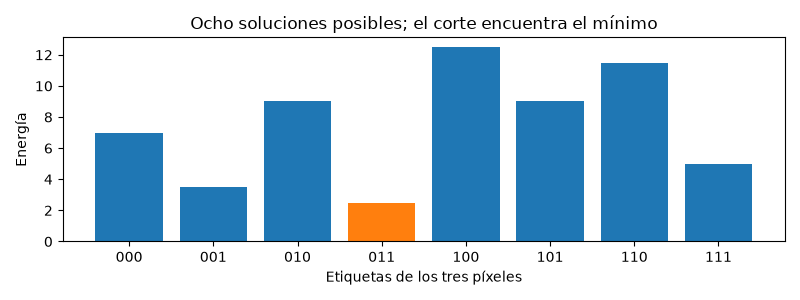

In [34]:
from itertools import product

toy_candidates = np.array(list(product([0, 1], repeat=3)))
toy_energies = np.array([
    toy_costs[np.arange(3), candidate].sum()
    + toy_weights[candidate[toy_edges[:, 0]] != candidate[toy_edges[:, 1]]].sum()
    for candidate in toy_candidates
])
best = toy_energies.argmin()
print("Mínimo exhaustivo:", toy_candidates[best], f"E = {toy_energies[best]:.3f}")
print("Corte mínimo:     ", toy_labels, f"E = {toy_flow + toy_offset:.3f}")
assert np.isclose(toy_energies[best], toy_flow + toy_offset)

fig, ax = plt.subplots(figsize=(8, 3))
colors = ["tab:orange" if i == best else "tab:blue" for i in range(8)]
ax.bar(["".join(map(str, row)) for row in toy_candidates], toy_energies, color=colors)
ax.set(xlabel="Etiquetas de los tres píxeles", ylabel="Energía", title="Ocho soluciones posibles; el corte encuentra el mínimo")
plt.tight_layout()
plt.show()

### 9.4. Primer corte sobre la imagen

Construimos de nuevo el grafo para resolverlo con sus capacidades originales. Los nodos alcanzables desde la fuente en el grafo residual final reciben etiqueta 1; los demás, etiqueta 0. El exterior de la ROI permanece en cero.

Verificamos una identidad que conecta toda la construcción:

$$E(\alpha^{\star};\theta)=
\operatorname{maxflow}+\sum_{i\in R}m_i+C_{\mathrm{fuera}}.$$

También calculamos la energía directamente sobre la imagen. Ambas expresiones deben coincidir hasta precisión numérica. El resultado es óptimo para estos GMM; todavía falta reajustarlos usando las etiquetas que acaba de producir el corte.

Energía directa:          1290056.504429
Flujo + constantes:      1290056.504429
Diferencia absoluta:     0.00e+00
Píxeles de primer plano: 0


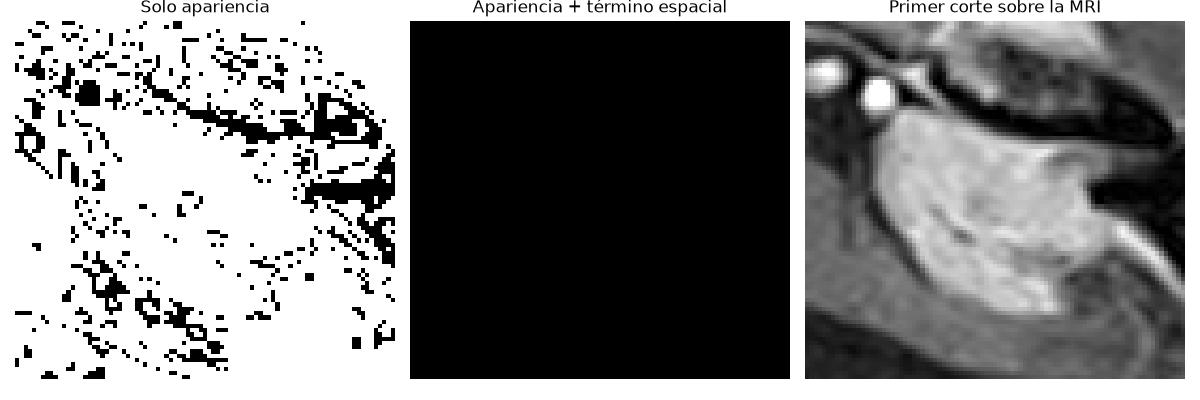

In [36]:
graph, source, sink, unary_offset = build_graph(roi_costs, roi_edges, roi_weights)
flow, reachable = maximum_flow(graph, source, sink)
first_labels = np.zeros_like(labels)
first_labels[roi_mask] = reachable[:roi_mask.sum()]

appearance_energy = np.take_along_axis(costs, first_labels[..., None], axis=-1).sum()
spatial_energy = edge_weights[first_labels.ravel()[edge_i] != first_labels.ravel()[edge_j]].sum()
cut_energy = appearance_energy + spatial_energy
flow_energy = flow + unary_offset + outside_cost
print(f"Energía directa:          {cut_energy:.6f}")
print(f"Flujo + constantes:      {flow_energy:.6f}")
print(f"Diferencia absoluta:     {abs(cut_energy - flow_energy):.2e}")
print(f"Píxeles de primer plano: {first_labels.sum():,}")
assert np.isclose(cut_energy, flow_energy)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(appearance_labels[roi_slice], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Solo apariencia")
axes[1].imshow(first_labels[roi_slice], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Apariencia + término espacial")
axes[2].imshow(image[roi_slice], cmap="gray")
axes[2].contour(first_labels[roi_slice], levels=[0.5], colors="cyan", linewidths=1)
axes[2].set_title("Primer corte sobre la MRI")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 9.5. Sensibilidad al peso espacial

Un corte mínimo puede ser **todo fondo**: no hay ninguna semilla obligatoria de primer plano y la ROI solo aporta una hipótesis inicial. Con los GMM actuales, un $\gamma$ grande puede hacer más barato eliminar la región que pagar su frontera.

Escribimos $E=U+\gamma V_1$ y comparamos $\gamma\in\{5,10,20,50\}$, sin cambiar los GMM ni la ROI. Como $\beta$ no depende de $\gamma$, basta escalar los enlaces y el costo de frontera por $\gamma_{\mathrm{nuevo}}/\gamma_{\mathrm{actual}}$.

Para continuar fijamos **$\gamma=10$** como elección didáctica de suavizado para el modelo unidimensional. No lo seleccionamos mediante la máscara de referencia, que se cargará al final. El valor 50 de OpenCV corresponde a otra implementación; no garantiza el mismo equilibrio con esta inicialización y estos modelos.

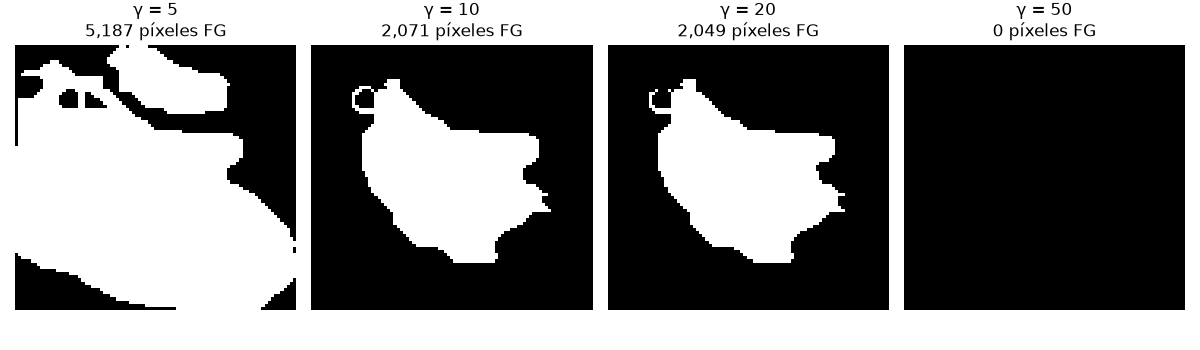

Continuamos con γ = 10 y 2,071 píxeles de primer plano.


In [39]:
gamma_values = [5.0, 10.0, 20.0, 50.0]
gamma_masks = []
fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))
for ax, trial_gamma in zip(axes, gamma_values):
    scale = trial_gamma / gamma
    trial_costs = costs[roi_mask].copy()
    trial_costs[:, 1] += boundary_cost * scale
    trial_graph, trial_source, trial_sink, offset = build_graph(
        trial_costs, roi_edges, roi_weights * scale
    )
    trial_flow, trial_reachable = maximum_flow(trial_graph, trial_source, trial_sink)
    trial_labels = np.zeros_like(labels)
    trial_labels[roi_mask] = trial_reachable[:roi_mask.sum()]
    gamma_masks.append(trial_labels)
    ax.imshow(trial_labels[roi_slice], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"γ = {trial_gamma:g}\n{trial_labels.sum():,} píxeles FG")
    ax.axis("off")
plt.tight_layout()
plt.show()

selected_gamma = 10.0
scale = selected_gamma / gamma
edge_weights = edge_weights * scale
roi_weights = roi_weights * scale
boundary_cost = boundary_cost * scale
gamma = selected_gamma
first_labels = gamma_masks[gamma_values.index(selected_gamma)].copy()
print(f"Continuamos con γ = {gamma:g} y {first_labels.sum():,} píxeles de primer plano.")

## 10. Iteración de GrabCut

### 10.1. Una vuelta completa con las nuevas etiquetas

La salida de un corte se convierte en la entrada de la siguiente vuelta:

$$\alpha^{(t)}\longrightarrow k^{(t)}\longrightarrow\theta^{(t+1)}
\longrightarrow D^{(t+1)}\longrightarrow\alpha^{(t+1)}.$$

1. Separamos las muestras usando las etiquetas actuales y asignamos componentes.
2. Actualizamos pesos, medias y varianzas de cada clase.
3. Recalculamos los costos de apariencia y añadimos el borde fijo de la ROI.
4. Construimos un grafo nuevo y resolvemos el corte mínimo.

Los pesos espaciales permanecen fijos porque dependen de la imagen, no de las etiquetas. El fondo seguro exterior **nunca cambia**. Ejecutamos una vuelta desde el corte elegido en 9.5 y contamos cuántas etiquetas cambian.

Etiquetas cambiadas: 141
Primer plano: 2,071 → 2,052 píxeles


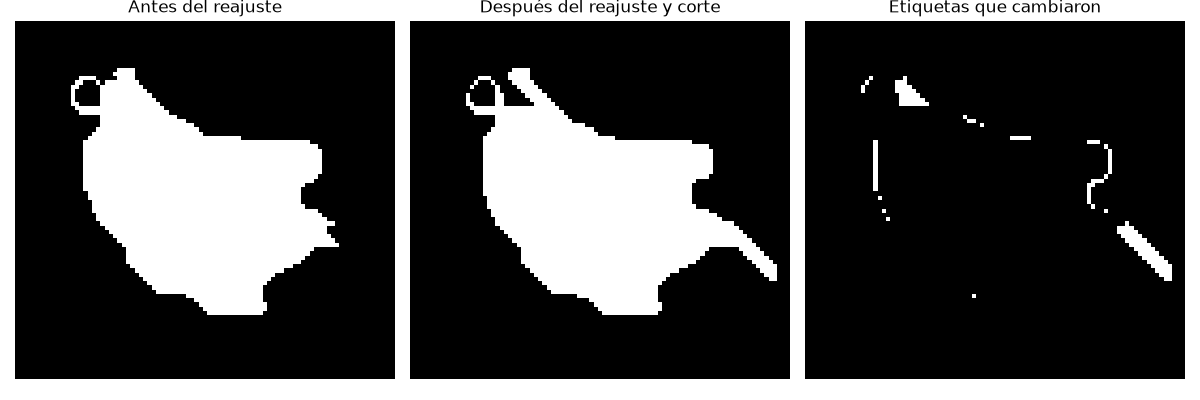

In [41]:
current_labels = first_labels.copy()
next_models = []
for a, model in enumerate(models):
    samples = values[current_labels == a]
    components = component_costs(samples, *model).argmin(axis=-1)
    next_models.append(update_gmm(samples, components, *model))

next_costs = np.stack([gmm_cost(values, *model) for model in next_models], axis=-1)
next_unary = next_costs[roi_mask].copy()
next_unary[:, 1] += boundary_cost
next_graph, next_source, next_sink, offset = build_graph(next_unary, roi_edges, roi_weights)
next_flow, next_reachable = maximum_flow(next_graph, next_source, next_sink)
next_labels = np.zeros_like(labels)
next_labels[roi_mask] = next_reachable[:roi_mask.sum()]
print(f"Etiquetas cambiadas: {np.count_nonzero(next_labels != current_labels):,}")
print(f"Primer plano: {current_labels.sum():,} → {next_labels.sum():,} píxeles")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, mask, title in zip(
    axes,
    [current_labels, next_labels, current_labels != next_labels],
    ["Antes del reajuste", "Después del reajuste y corte", "Etiquetas que cambiaron"],
):
    ax.imshow(mask[roi_slice], cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

### 10.2. Implementación didáctica completa

Reunimos los pasos anteriores en una función que vuelve a iniciar desde la ROI. Recibe la imagen, la máscara del rectángulo, los pares internos, sus pesos y los costos de frontera ya calculados.

En cada vuelta asigna componentes, ajusta los dos GMM y resuelve un corte. Guardamos las máscaras y la energía reducida de la ROI **antes y después de cada corte**, evaluadas con los mismos parámetros de esa vuelta:

$$E_R(\alpha^{(t+1)};\theta^{(t+1)})\le
E_R(\alpha^{(t)};\theta^{(t+1)}).$$

Esta desigualdad corresponde al corte. No presupone descenso entre vueltas, pues al ajustar los GMM cambiamos los costos y usamos asignaciones duras con un costo marginal.

Ejecutamos cinco vueltas, también para la comparación posterior con OpenCV. No detenemos el ciclo por una sola vuelta sin cambios de etiquetas: los parámetros gaussianos aún podrían cambiar. El resultado no es una garantía de óptimo conjunto de etiquetas y modelos.

In [43]:
def didactic_grabcut(image, roi_mask, edges, weights, boundary_cost, K=5, iterations=5):
    values = image.astype(np.float64)
    result = roi_mask.astype(np.uint8)
    models = [initialize_gmm(values[result == a], K) for a in (0, 1)]
    masks = [result.copy()]
    diagnostics = []
    node_ids = np.arange(roi_mask.sum())

    for iteration in range(iterations):
        for a in (0, 1):
            samples = values[result == a]
            components = component_costs(samples, *models[a]).argmin(axis=-1)
            models[a] = update_gmm(samples, components, *models[a])

        unary = np.column_stack([gmm_cost(values[roi_mask], *model) for model in models])
        unary[:, 1] += boundary_cost
        previous = result[roi_mask].copy()
        before = unary[node_ids, previous].sum()
        before += weights[previous[edges[:, 0]] != previous[edges[:, 1]]].sum()

        graph, source, sink, offset = build_graph(unary, edges, weights)
        flow, reachable = maximum_flow(graph, source, sink)
        result[roi_mask] = reachable[:len(node_ids)]
        changed = np.count_nonzero(result[roi_mask] != previous)
        diagnostics.append((changed, before, flow + offset))
        masks.append(result.copy())

    return result, masks, np.array(diagnostics)


iterations = 5
didactic_mask, label_history, diagnostics = didactic_grabcut(
    image, roi_mask, roi_edges, roi_weights, boundary_cost, K=K, iterations=iterations
)
print("Vuelta  Cambios    Energía antes    Energía después")
for iteration, (changed, before, after) in enumerate(diagnostics, start=1):
    print(f"{iteration:6d}  {int(changed):7,d}  {before:15.3f}  {after:17.3f}")

Vuelta  Cambios    Energía antes    Energía después
     1    5,405        47253.666          42601.629
     2      141        40868.344          40700.957
     3       10        40648.578          40642.875
     4        0        40627.496          40627.496
     5        2        40619.990          40619.959


### 10.3. Evolución de la segmentación

Mostramos $\alpha^{(0)},\ldots,\alpha^{(5)}$ dentro de la misma ROI, con blanco para primer plano y negro para fondo. La inicialización llena todo el rectángulo; los cortes posteriores delimitan la región según apariencia y contraste.

El conteo de píxeles permite relacionar cada imagen con la tabla anterior. Pocas etiquetas cambiadas indican estabilidad de la segmentación observada, no exactitud frente a la anotación. La referencia todavía no ha intervenido en el ajuste.

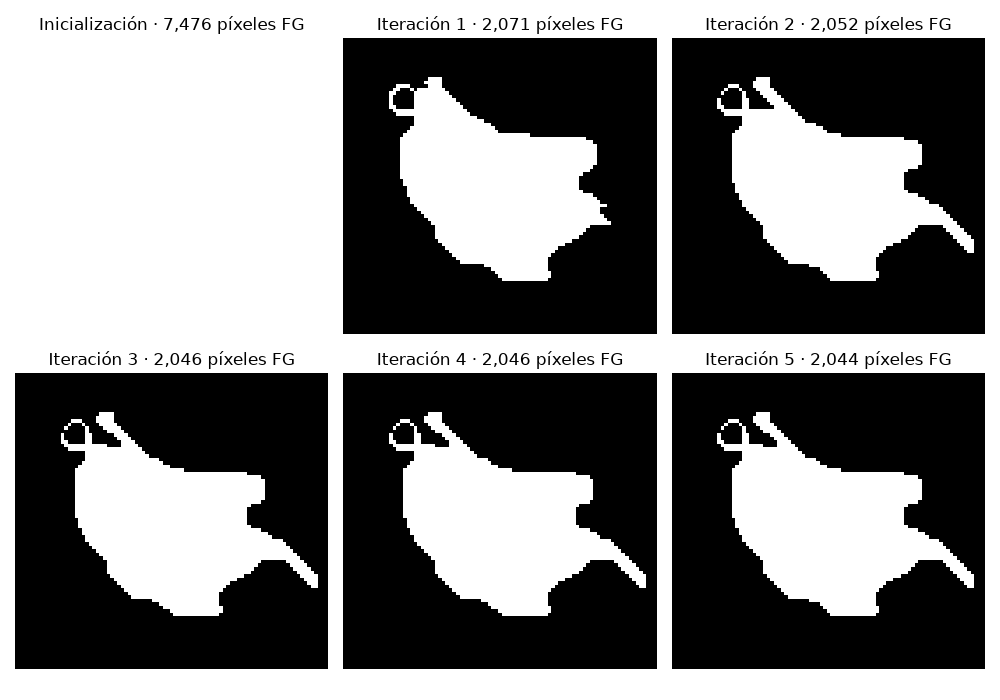

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for iteration, (ax, mask) in enumerate(zip(axes.flat, label_history)):
    ax.imshow(mask[roi_slice], cmap="gray", vmin=0, vmax=1)
    title = "Inicialización" if iteration == 0 else f"Iteración {iteration}"
    ax.set_title(f"{title} · {mask.sum():,} píxeles FG")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 11. GrabCut con OpenCV

`cv2.grabCut` reúne inicialización de GMM, reajuste y cortes sucesivos. Usa cuatro etiquetas:

| Valor | Constante | Significado |
|---|---|---|
| 0 | `GC_BGD` | Fondo seguro |
| 1 | `GC_FGD` | Primer plano seguro |
| 2 | `GC_PR_BGD` | Fondo probable |
| 3 | `GC_PR_FGD` | Primer plano probable |

Con `GC_INIT_WITH_RECT`, el exterior del mismo rectángulo es fondo seguro y su interior, primer plano probable. Al finalizar extraemos $\widehat\alpha_i=1$ para los valores 1 o 3.

La API requiere tres canales de 8 bits: replicamos la intensidad gris en BGR, sin añadir información de color. Los arreglos `(1, 65)` almacenan los cinco componentes de cada GMM tridimensional. Fijamos la semilla y usamos las mismas cinco vueltas.

La comparación es conceptual, no una reproducción exacta: nuestra versión usa gaussianas unidimensionales, particiones ordenadas, asignación ponderada y $\gamma=10$; OpenCV usa k-means, covarianzas tridimensionales regularizadas, otra regla de asignación y $\gamma=50$. Véanse la [documentación de la API](https://docs.opencv.org/4.x/d8/d83/tutorial_py_grabcut.html) y la [implementación de OpenCV](https://github.com/opencv/opencv/blob/5.x/modules/imgproc/src/grabcut.cpp).

En la ejecución guardada, OpenCV conserva solo dos píxeles de primer plano. La inicialización rectangular no impone ninguna semilla segura de lesión y puede llegar a una solución casi vacía. Conservamos esa salida para discutir sus errores y el desbalance entre fondo y lesión; no se debe interpretar como una superioridad general de una implementación sobre la otra.


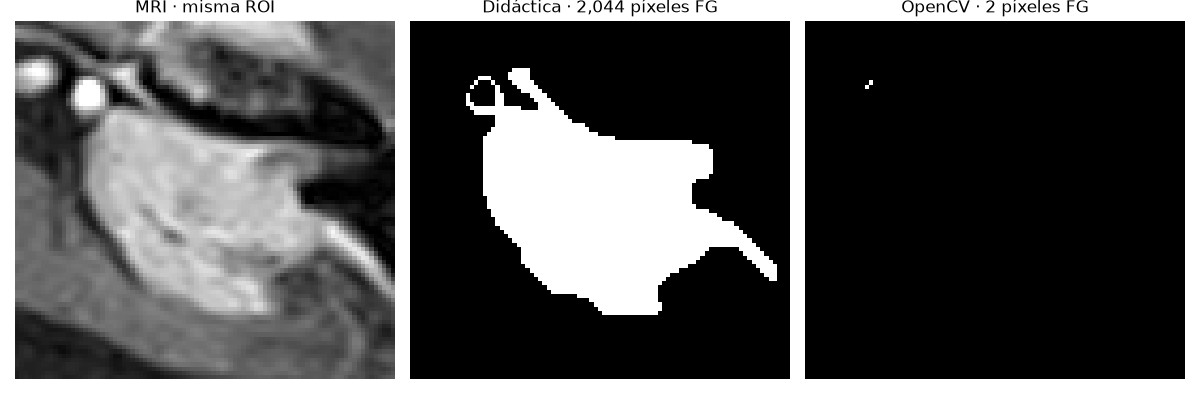

OpenCV 5.0.0; vueltas: 5; ROI: (250, 253, 89, 84)


In [46]:
image_bgr = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
opencv_labels = np.zeros_like(image, dtype=np.uint8)
background_model = np.zeros((1, 65), dtype=np.float64)
foreground_model = np.zeros((1, 65), dtype=np.float64)
rectangle = tuple(roi_state["value"])
cv2.setRNGSeed(0)
cv2.grabCut(
    image_bgr, opencv_labels, rectangle,
    background_model, foreground_model, iterations, cv2.GC_INIT_WITH_RECT
)
opencv_mask = np.isin(opencv_labels, [cv2.GC_FGD, cv2.GC_PR_FGD]).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image[roi_slice], cmap="gray")
axes[0].set_title("MRI · misma ROI")
for ax, mask, title in zip(axes[1:], [didactic_mask, opencv_mask], ["Didáctica", "OpenCV"]):
    ax.imshow(mask[roi_slice], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{title} · {mask.sum():,} píxeles FG")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"OpenCV {cv2.__version__}; vueltas: {iterations}; ROI: {rectangle}")

## 12. Máscara de referencia (ground truth)

El archivo de `data/contours/` de este caso no es una máscara binaria: contiene la MRI en gris con la lesión **rellena en rojo**. El tejido sin marcar tiene canales iguales; la marca roja cumple $R_i>G_i$ y $R_i>B_i$.

Por tanto, obtenemos la referencia mediante

$$g_i=[R_i>G_i\ \land\ R_i>B_i],\qquad g_i\in\{0,1\}.$$

No aplicamos umbral de intensidad a la MRI, no rellenamos contornos adicionales ni recortamos la referencia al rectángulo. Mantenerla completa permite penalizar también una ROI que deje parte de la lesión fuera. Esta máscara se usa **solo para evaluar**, después de ejecutar ambas segmentaciones.

Mostramos la anotación, la máscara extraída y su contorno sobre la imagen original para comprobar posición, orientación y extensión.

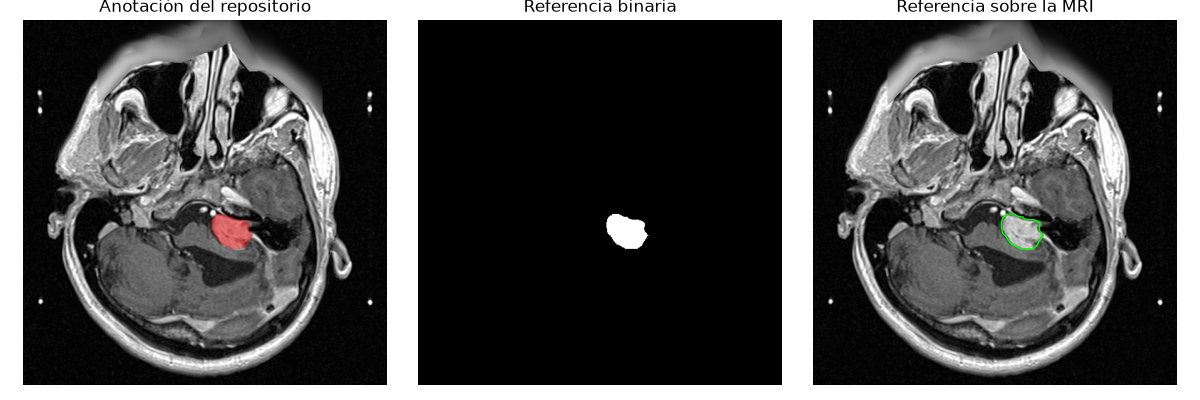

Píxeles anotados: 2,071
Píxeles anotados fuera de la ROI: 0


In [48]:
annotation_path = DATA_DIR / "contours" / f"{case_id}.png"
annotation_bgr = cv2.imread(str(annotation_path), cv2.IMREAD_COLOR)
blue, green, red = cv2.split(annotation_bgr)
ground_truth = ((red > green) & (red > blue)).astype(np.uint8)
annotation_rgb = cv2.cvtColor(annotation_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(annotation_rgb)
axes[0].set_title("Anotación del repositorio")
axes[1].imshow(ground_truth, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Referencia binaria")
axes[2].imshow(image, cmap="gray")
axes[2].contour(ground_truth, levels=[0.5], colors="lime", linewidths=1)
axes[2].set_title("Referencia sobre la MRI")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"Píxeles anotados: {ground_truth.sum():,}")
print(f"Píxeles anotados fuera de la ROI: {ground_truth[~roi_mask].sum():,}")

## 13. Comparación cuantitativa y visual

### 13.1. Error cuadrático medio (MSE o ECM)

Para $N$ píxeles y máscaras binarias $\widehat\alpha_i,g_i\in\{0,1\}$,

$$\operatorname{MSE}=\frac1N\sum_{i=1}^{N}(\widehat\alpha_i-g_i)^2
=\frac{\mathrm{FP}+\mathrm{FN}}{N}.$$

El MSE es la fracción de píxeles mal clasificados: 0 significa coincidencia completa y 1 desacuerdo en todos. Usamos valores 0/1 y convertimos a flotante **antes de restar**, evitando el desbordamiento de `uint8`. Con máscaras 0/255 el resultado quedaría multiplicado por $255^2$.

Informamos el MSE en la imagen completa y, como complemento, dentro de la ROI. También contamos falsos positivos (FP) y falsos negativos (FN) en toda la imagen.

La lesión ocupa una parte pequeña de la imagen. Por eso añadimos la referencia trivial **todo fondo**: puede tener MSE global pequeño aunque no detecte lesión alguna. El resultado de OpenCV se evalúa tal como salió, incluso si es casi vacío. Estos números describen este caso y esta ROI, no el rendimiento general sobre el dataset.

Método            FP      FN    MSE global      MSE ROI
Didáctica        178     205      0.001461     0.051231
OpenCV             2   2,071      0.007908     0.277287
Todo fondo         0   2,071      0.007900     0.277020


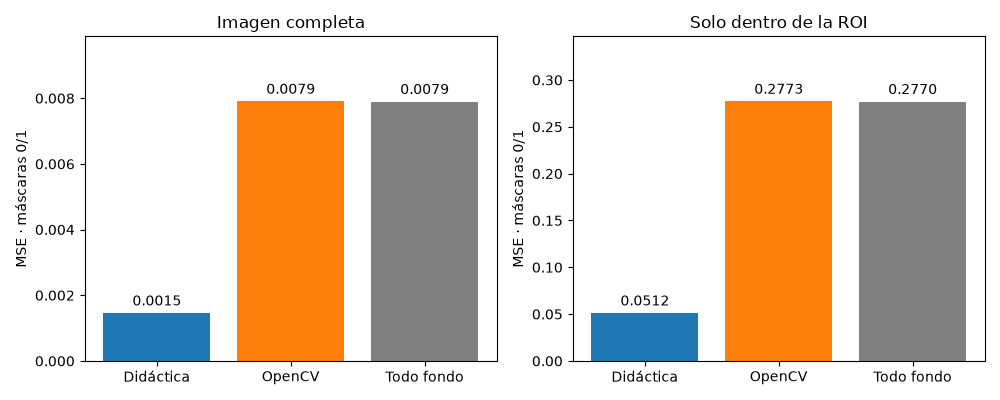

In [50]:
predictions = [
    ("Didáctica", didactic_mask),
    ("OpenCV", opencv_mask),
    ("Todo fondo", np.zeros_like(ground_truth)),
]
metrics = []
print(f"{'Método':12s} {'FP':>7s} {'FN':>7s} {'MSE global':>13s} {'MSE ROI':>12s}")
for name, mask in predictions:
    squared_error = (mask.astype(np.float64) - ground_truth.astype(np.float64)) ** 2
    mse_full = squared_error.mean()
    mse_roi = squared_error[roi_mask].mean()
    false_positives = np.count_nonzero((mask == 1) & (ground_truth == 0))
    false_negatives = np.count_nonzero((mask == 0) & (ground_truth == 1))
    metrics.append((mse_full, mse_roi, false_positives, false_negatives))
    print(f"{name:12s} {false_positives:7,d} {false_negatives:7,d} {mse_full:13.6f} {mse_roi:12.6f}")
metrics = np.array(metrics)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for column, (ax, title) in enumerate(zip(axes, ["Imagen completa", "Solo dentro de la ROI"])):
    bars = ax.bar([name for name, mask in predictions], metrics[:, column], color=["tab:blue", "tab:orange", "gray"])
    ax.bar_label(bars, fmt="%.4f", padding=3)
    ax.set(title=title, ylabel="MSE · máscaras 0/1", ylim=(0, metrics[:, column].max() * 1.25))
plt.tight_layout()
plt.show()

### 13.2. Dónde se cometen los errores

Un único número no explica los errores. Superponemos en la ROI el contorno de referencia en **verde** y el predicho en **magenta**. Debajo construimos un mapa discreto:

$$e_i=\begin{cases}
0,&g_i=0,\ \widehat\alpha_i=0\quad\text{(fondo correcto)},\\
1,&g_i=1,\ \widehat\alpha_i=1\quad\text{(lesión detectada)},\\
2,&g_i=0,\ \widehat\alpha_i=1\quad\text{(falso positivo)},\\
3,&g_i=1,\ \widehat\alpha_i=0\quad\text{(falso negativo)}.
\end{cases}$$

Los errores rojos son exceso de segmentación y los cian, lesión omitida. La figura amplía la ROI; la tabla anterior sí evalúa la imagen completa, incluso cualquier referencia fuera del rectángulo.

Para cerrar la exposición: ¿qué aporta el GMM?, ¿qué corrige el término espacial?, ¿por qué un corte óptimo puede dar una mala segmentación?, ¿por qué un MSE global pequeño puede ser engañoso?

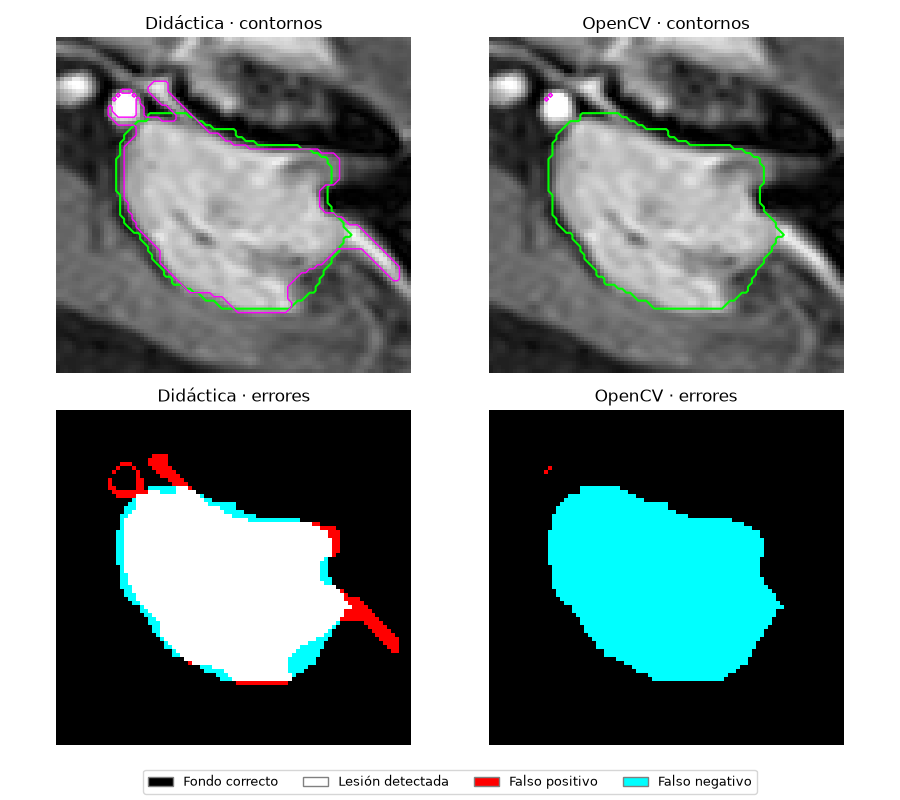

In [52]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

error_colors = ["black", "white", "red", "cyan"]
error_names = ["Fondo correcto", "Lesión detectada", "Falso positivo", "Falso negativo"]
fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for column, (name, mask) in enumerate(predictions[:2]):
    axes[0, column].imshow(image[roi_slice], cmap="gray")
    axes[0, column].contour(ground_truth[roi_slice], levels=[0.5], colors="lime", linewidths=1.5)
    axes[0, column].contour(mask[roi_slice], levels=[0.5], colors="magenta", linewidths=1)
    axes[0, column].set_title(f"{name} · contornos")

    error_map = np.zeros_like(mask)
    error_map[(mask == 1) & (ground_truth == 1)] = 1
    error_map[(mask == 1) & (ground_truth == 0)] = 2
    error_map[(mask == 0) & (ground_truth == 1)] = 3
    axes[1, column].imshow(error_map[roi_slice], cmap=ListedColormap(error_colors), vmin=-0.5, vmax=3.5, interpolation="nearest")
    axes[1, column].set_title(f"{name} · errores")
for ax in axes.flat:
    ax.axis("off")
fig.legend(
    handles=[Patch(facecolor=color, edgecolor="gray", label=name) for color, name in zip(error_colors, error_names)],
    loc="lower center", ncol=4, fontsize=9,
)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()